# **1. Perkenalan Dataset**

Notebook ini mengikuti Template Eksperimen MSML. Dataset yang digunakan adalah **Titanic Dataset** untuk menyelesaikan masalah klasifikasi biner: memprediksi apakah penumpang selamat (`Survived = 1`) atau tidak selamat (`Survived = 0`).

Dataset berisi informasi penumpang seperti kelas tiket (`Pclass`), jenis kelamin (`Sex`), usia (`Age`), jumlah saudara/pasangan (`SibSp`), jumlah orang tua/anak (`Parch`), tarif (`Fare`), kabin (`Cabin`), dan pelabuhan keberangkatan (`Embarked`).

Tujuan eksperimen:
1. Memuat dataset Titanic.
2. Melakukan Exploratory Data Analysis (EDA).
3. Melakukan preprocessing manual.
4. Menyimpan dataset hasil preprocessing dalam bentuk `train.csv` dan `test.csv`.
5. Menjadikan notebook ini sebagai panduan untuk membuat file otomatisasi preprocessing.

# **2. Import Library**

Pada tahap ini, library yang digunakan mencakup `pandas`, `numpy`, `matplotlib`, `seaborn`, serta modul preprocessing dari `scikit-learn`.

In [1]:
import os
import json
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

# **3. Memuat Dataset**

Dataset dimuat dari folder `namadataset_raw`. Jika notebook dijalankan dari folder `preprocessing`, path yang digunakan adalah `../namadataset_raw/titanic.csv`.

In [3]:
import pandas as pd
from google.colab import files
import io

TARGET_COLUMN = 'Survived'

# Upload file CSV
uploaded = files.upload()

# Ambil nama file yang diupload
file_name = list(uploaded.keys())[0]

# Baca file CSV
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

df.head()

Saving titanic.csv to titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
print('Shape dataset:', df.shape)
df.info()

Shape dataset: (891, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini dilakukan analisis awal untuk memahami karakteristik dataset Titanic, termasuk distribusi target, missing value, duplikasi data, distribusi fitur numerik, dan hubungan fitur dengan target.

In [6]:
# Cek missing value
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [7]:
# Cek data duplikat
print('Jumlah data duplikat:', df.duplicated().sum())

Jumlah data duplikat: 0


Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


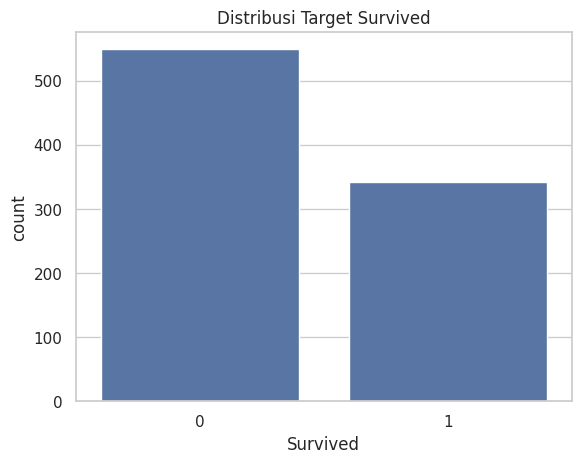

In [8]:
# Distribusi target
print(df[TARGET_COLUMN].value_counts())
print(df[TARGET_COLUMN].value_counts(normalize=True))

sns.countplot(data=df, x=TARGET_COLUMN)
plt.title('Distribusi Target Survived')
plt.show()

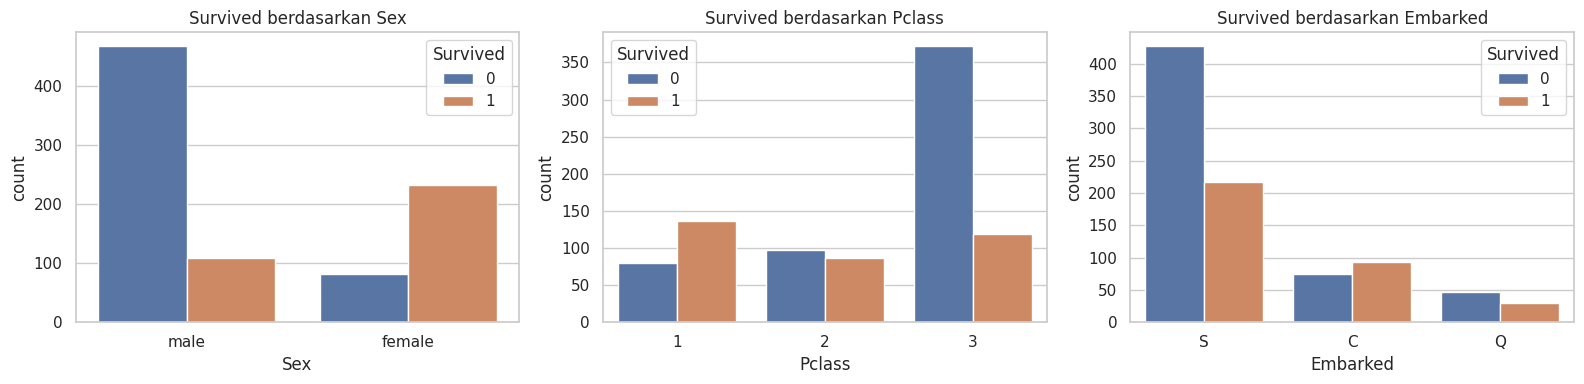

In [9]:
# Distribusi fitur kategorikal terhadap target
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.countplot(data=df, x='Sex', hue=TARGET_COLUMN, ax=axes[0])
axes[0].set_title('Survived berdasarkan Sex')
sns.countplot(data=df, x='Pclass', hue=TARGET_COLUMN, ax=axes[1])
axes[1].set_title('Survived berdasarkan Pclass')
sns.countplot(data=df, x='Embarked', hue=TARGET_COLUMN, ax=axes[2])
axes[2].set_title('Survived berdasarkan Embarked')
plt.tight_layout()
plt.show()

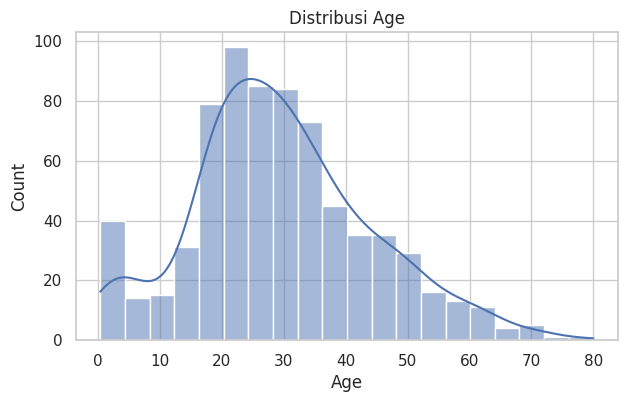

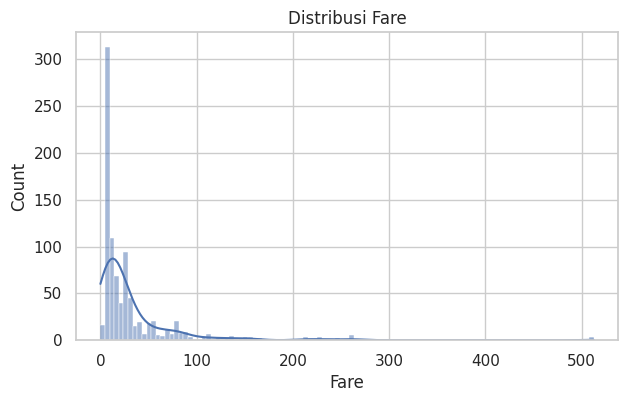

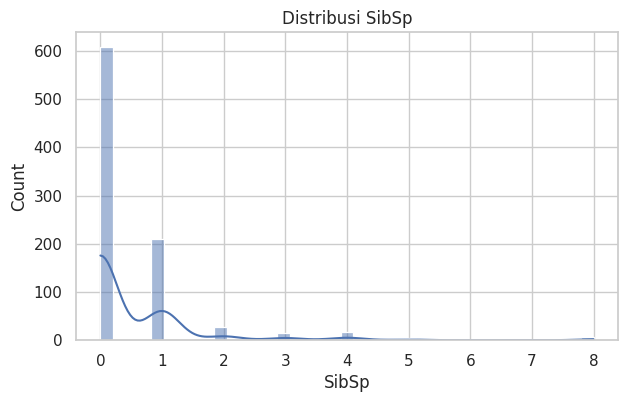

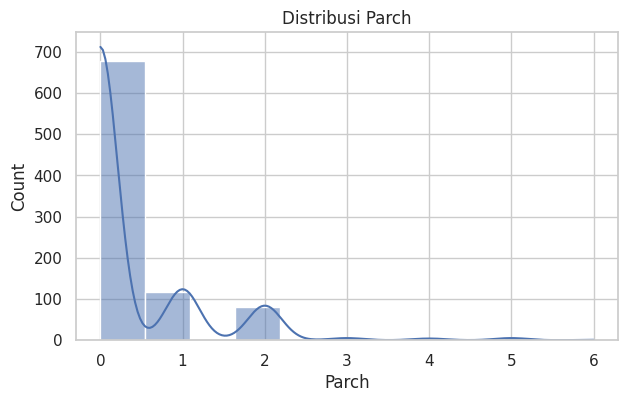

In [10]:
# Distribusi fitur numerik
numeric_cols = ['Age', 'Fare', 'SibSp', 'Parch']
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribusi {col}')
    plt.show()

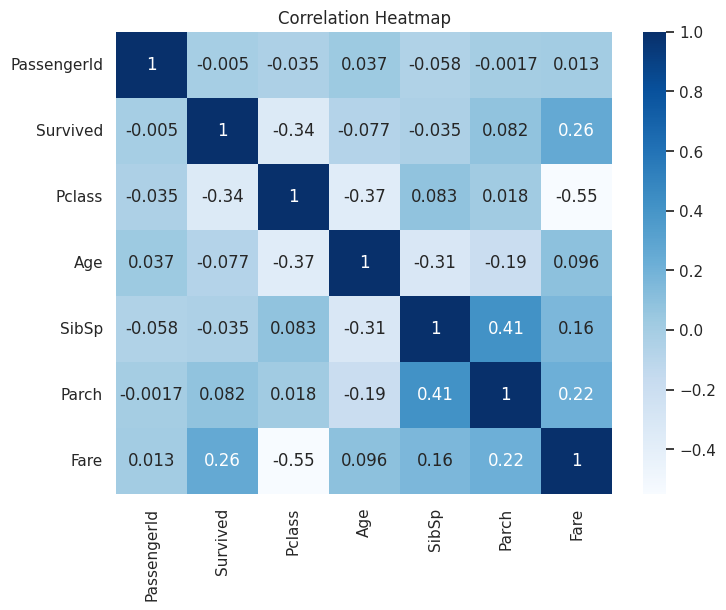

In [11]:
# Korelasi fitur numerik
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Heatmap')
plt.show()

# **5. Data Preprocessing**

Tahap preprocessing dilakukan untuk mengubah dataset mentah menjadi dataset yang siap dilatih oleh model machine learning. Tahapan yang dilakukan:

1. Menghapus data duplikat.
2. Membuat fitur baru `FamilySize` dan `IsAlone`.
3. Mengisi missing value pada `Age`, `Fare`, dan `Embarked`.
4. Menghapus kolom yang tidak digunakan: `PassengerId`, `Name`, `Ticket`, dan `Cabin`.
5. Membagi data menjadi train dan test.
6. Melakukan scaling fitur numerik dan encoding fitur kategorikal.
7. Menyimpan hasil preprocessing ke `train.csv`, `test.csv`, dan `preprocessing_metadata.json`.

In [12]:
df_processed = df.copy()
df_processed = df_processed.drop_duplicates()

# Feature engineering
df_processed['FamilySize'] = df_processed['SibSp'] + df_processed['Parch'] + 1
df_processed['IsAlone'] = (df_processed['FamilySize'] == 1).astype(int)

# Handling missing value
df_processed['Age'] = df_processed['Age'].fillna(df_processed['Age'].median())
df_processed['Fare'] = df_processed['Fare'].fillna(df_processed['Fare'].median())
df_processed['Embarked'] = df_processed['Embarked'].fillna(df_processed['Embarked'].mode()[0])

# Drop kolom yang tidak digunakan
drop_columns = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_processed = df_processed.drop(columns=[col for col in drop_columns if col in df_processed.columns])

df_processed.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1


In [13]:
# Split dataset
X = df_processed.drop(columns=[TARGET_COLUMN])
y = df_processed[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (712, 9)
X_test: (179, 9)


In [14]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
categorical_features = ['Sex', 'Embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', make_one_hot_encoder(), categorical_features),
    ],
    remainder='drop'
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = list(preprocessor.get_feature_names_out())

train_df = pd.DataFrame(X_train_processed, columns=feature_names)
train_df[TARGET_COLUMN] = y_train.reset_index(drop=True)

test_df = pd.DataFrame(X_test_processed, columns=feature_names)
test_df[TARGET_COLUMN] = y_test.reset_index(drop=True)

train_df.head()

,num__Pclass,num__Age,num__SibSp,num__Parch,num__Fare,num__FamilySize,num__IsAlone,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,Survived
0,0.829568,-0.112078,-0.465084,-0.466183,0.513812,-0.556339,0.800346,0.0,1.0,0.0,0.0,1.0,1
1,-0.370945,-0.112078,-0.465084,-0.466183,-0.662563,-0.556339,0.800346,0.0,1.0,0.0,0.0,1.0,0
2,-1.571457,-0.112078,-0.465084,-0.466183,3.955399,-0.556339,0.800346,0.0,1.0,0.0,0.0,1.0,0
3,0.829568,-0.879807,-0.465084,0.727782,-0.467874,0.073412,-1.249460,1.0,0.0,0.0,0.0,1.0,1
4,-0.370945,0.118241,0.478335,0.727782,-0.115977,0.703162,-1.249460,1.0,0.0,0.0,0.0,1.0,1


In [15]:
OUTPUT_DIR = 'namadataset_preprocessing'
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_path = os.path.join(OUTPUT_DIR, 'train.csv')
test_path = os.path.join(OUTPUT_DIR, 'test.csv')
metadata_path = os.path.join(OUTPUT_DIR, 'preprocessing_metadata.json')

train_df.to_csv(train_path, index=False)
test_df.to_csv(test_path, index=False)

metadata = {
    'dataset_name': 'Titanic Dataset',
    'target_column': TARGET_COLUMN,
    'raw_shape': list(df.shape),
    'processed_train_shape': list(train_df.shape),
    'processed_test_shape': list(test_df.shape),
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'drop_columns': drop_columns,
    'feature_names': feature_names,
    'created_at': datetime.now().isoformat(),
}

with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=4)

print('Dataset preprocessing berhasil disimpan:')
print(train_path)
print(test_path)
print(metadata_path)

Dataset preprocessing berhasil disimpan:
namadataset_preprocessing/train.csv
namadataset_preprocessing/test.csv
namadataset_preprocessing/preprocessing_metadata.json


## Kesimpulan Preprocessing

Dataset Titanic telah diproses menjadi data numerik yang siap digunakan untuk training model. Seluruh proses pada notebook ini dikonversi ke dalam file `automate_MuhammadSidiqFirdaus.py` agar preprocessing dapat dijalankan secara otomatis melalui terminal maupun GitHub Actions.